In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ydata_profiling import ProfileReport


/tmp/ipykernel_4204/67796275.py:5: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


In [2]:
df = pd.read_csv("/home/tanmoy/Desktop/Phitron/Machine Learning/Module6 - Outlires Ditection and Handling/Practice/titanic_data_updated.csv")
df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,no,third,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,yes,first,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,yes,third,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,yes,first,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,no,third,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.drop(columns=['PassengerId', 'Name', 'Ticket'], inplace=True)
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,no,third,male,22.0,1,0,7.2500,NaN,S
1,yes,first,female,38.0,1,0,71.2833,C85,C
2,yes,third,female,26.0,0,0,7.9250,NaN,S
3,yes,first,female,35.0,1,0,53.1000,C123,S
4,no,third,male,35.0,0,0,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...
886,no,second,male,27.0,0,0,13.0000,NaN,S
887,yes,first,female,19.0,0,0,30.0000,B42,S
888,no,third,female,NaN,1,2,23.4500,NaN,S
889,yes,first,male,26.0,0,0,30.0000,C148,C


In [4]:
df.isnull().sum()

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Cabin       687
Embarked      2
dtype: int64

In [5]:
df.sample(5)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
472,yes,second,female,33.0,1,2,27.7500,NaN,S
445,yes,first,male,4.0,0,2,81.8583,A34,S
559,yes,third,female,36.0,1,0,17.4000,NaN,S
33,no,second,male,66.0,0,0,10.5000,NaN,S
730,yes,first,female,29.0,0,0,211.3375,B5,S


In [6]:
print(df['Age'].isnull().sum())

177


## Feature and taget column ke alada kora 

In [7]:
x = df.drop(columns=['Survived'])
x.head(5)

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,third,male,22.0,1,0,7.2500,NaN,S
1,first,female,38.0,1,0,71.2833,C85,C
2,third,female,26.0,0,0,7.9250,NaN,S
3,first,female,35.0,1,0,53.1000,C123,S
4,third,male,35.0,0,0,8.0500,NaN,S


In [8]:
y = df['Survived']
y.head(5)

0     no
1    yes
2    yes
3    yes
4     no
Name: Survived, dtype: object

## Train Test Split

In [9]:
from sklearn.model_selection import train_test_split

In [10]:
train_x, test_x, train_y, test_y = train_test_split(x, y, test_size=0.2, random_state=42)

In [11]:
train_x

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
331,first,male,45.5,0,0,28.5000,C124,S
733,second,male,23.0,0,0,13.0000,NaN,S
382,third,male,32.0,0,0,7.9250,NaN,S
704,third,male,26.0,1,0,7.8542,NaN,S
813,third,female,6.0,4,2,31.2750,NaN,S
...,...,...,...,...,...,...,...,...
106,third,female,21.0,0,0,7.6500,NaN,S
270,first,male,NaN,0,0,31.0000,NaN,S
860,third,male,41.0,2,0,14.1083,NaN,S
435,first,female,14.0,1,2,120.0000,B96 B98,S


In [12]:
test_x

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
709,third,male,NaN,1,1,15.2458,NaN,C
439,second,male,31.0,0,0,10.5000,NaN,S
840,third,male,20.0,0,0,7.9250,NaN,S
720,second,female,6.0,0,1,33.0000,NaN,S
39,third,female,14.0,1,0,11.2417,NaN,C
...,...,...,...,...,...,...,...,...
433,third,male,17.0,0,0,7.1250,NaN,S
773,third,male,NaN,0,0,7.2250,NaN,C
25,third,female,38.0,1,5,31.3875,NaN,S
84,second,female,17.0,0,0,10.5000,NaN,S


## Filling missing using pandas

In [13]:
mn = train_x['Age'].mean()
mn

np.float64(29.498846153846156)

In [14]:
train_x['mean'] = train_x['Age'].fillna(mn)
train_x



,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,mean
331,first,male,45.5,0,0,28.5000,C124,S,45.500000
733,second,male,23.0,0,0,13.0000,NaN,S,23.000000
382,third,male,32.0,0,0,7.9250,NaN,S,32.000000
704,third,male,26.0,1,0,7.8542,NaN,S,26.000000
813,third,female,6.0,4,2,31.2750,NaN,S,6.000000
...,...,...,...,...,...,...,...,...,...
106,third,female,21.0,0,0,7.6500,NaN,S,21.000000
270,first,male,NaN,0,0,31.0000,NaN,S,29.498846
860,third,male,41.0,2,0,14.1083,NaN,S,41.000000
435,first,female,14.0,1,2,120.0000,B96 B98,S,14.000000


In [15]:
train_x['mean'].isnull().sum()

np.int64(0)

In [16]:
md = df['Age'].median()
md

28.0

In [17]:
train_x['mode'] = train_x['Age'].fillna(md)
train_x

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,mean,mode
331,first,male,45.5,0,0,28.5000,C124,S,45.500000,45.5
733,second,male,23.0,0,0,13.0000,NaN,S,23.000000,23.0
382,third,male,32.0,0,0,7.9250,NaN,S,32.000000,32.0
704,third,male,26.0,1,0,7.8542,NaN,S,26.000000,26.0
813,third,female,6.0,4,2,31.2750,NaN,S,6.000000,6.0
...,...,...,...,...,...,...,...,...,...,...
106,third,female,21.0,0,0,7.6500,NaN,S,21.000000,21.0
270,first,male,NaN,0,0,31.0000,NaN,S,29.498846,28.0
860,third,male,41.0,2,0,14.1083,NaN,S,41.000000,41.0
435,first,female,14.0,1,2,120.0000,B96 B98,S,14.000000,14.0


In [18]:
train_x['mode'].isnull().sum()

np.int64(0)

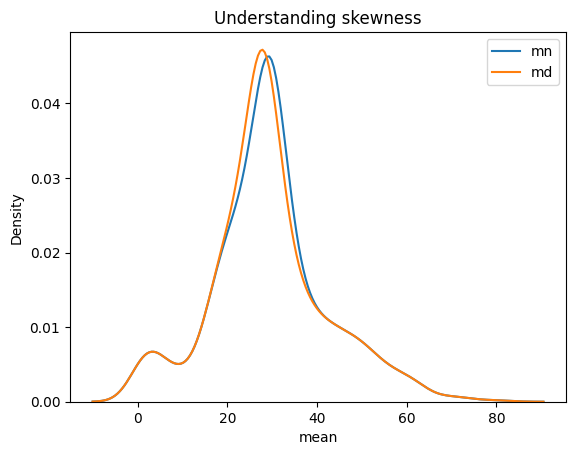

In [19]:
plt.title("Understanding skewness")
sns.kdeplot(data=train_x, x = 'mean', label='mn')
sns.kdeplot(data=train_x, x = 'mode', label='md')
plt.legend()
plt.show()

## Sklearn diye dekhbo ekhon 

In [20]:
from sklearn.impute import SimpleImputer

age_imputer = SimpleImputer(missing_values=np.nan, strategy='mean')

age_imputer.fit(train_x[['Age']])
train_x['Age'] = age_imputer.transform(train_x[['Age']])

In [21]:
train_x.isnull().sum()

Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Cabin       553
Embarked      2
mean          0
mode          0
dtype: int64

In [22]:
age_imputer.fit(test_x[['Age']])
test_x['Age'] = age_imputer.transform(test_x[['Age']])

In [23]:
test_x.isnull().sum()

Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Cabin       134
Embarked      0
dtype: int64

In [24]:
from sklearn.impute import SimpleImputer

e = SimpleImputer(missing_values=np.nan, strategy='most_frequent')

e.fit(train_x[['Embarked']])

train_x['Embarked'] = e.transform(train_x[['Embarked']]).ravel()
test_x['Embarked'] = e.transform(test_x[['Embarked']]).ravel()

In [25]:
train_x.isnull().sum()

Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Cabin       553
Embarked      0
mean          0
mode          0
dtype: int64

In [26]:
test_x.isnull().sum()

Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Cabin       134
Embarked      0
dtype: int64

In [27]:
cabin_update = SimpleImputer(missing_values=np.nan, strategy='constant', fill_value='Missing', add_indicator=True)

cabin_update.fit(train_x[['Cabin']])

train_x[['Cabin', 'cabin_missing_indicator']] = cabin_update.transform(train_x[['Cabin']])
test_x[['Cabin', 'cabin_missing_indicator']] = cabin_update.transform(test_x[['Cabin']])

In [28]:
train_x.isnull().sum()

Pclass                     0
Sex                        0
Age                        0
SibSp                      0
Parch                      0
Fare                       0
Cabin                      0
Embarked                   0
mean                       0
mode                       0
cabin_missing_indicator    0
dtype: int64

In [29]:
test_x.isnull().sum()

Pclass                     0
Sex                        0
Age                        0
SibSp                      0
Parch                      0
Fare                       0
Cabin                      0
Embarked                   0
cabin_missing_indicator    0
dtype: int64

## Outlires handling

In [30]:
train_x.drop(columns=['mean','mode', 'cabin_missing_indicator'], inplace=True)

In [31]:
train_x

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
331,first,male,45.500000,0,0,28.5000,C124,S
733,second,male,23.000000,0,0,13.0000,Missing,S
382,third,male,32.000000,0,0,7.9250,Missing,S
704,third,male,26.000000,1,0,7.8542,Missing,S
813,third,female,6.000000,4,2,31.2750,Missing,S
...,...,...,...,...,...,...,...,...
106,third,female,21.000000,0,0,7.6500,Missing,S
270,first,male,29.498846,0,0,31.0000,Missing,S
860,third,male,41.000000,2,0,14.1083,Missing,S
435,first,female,14.000000,1,2,120.0000,B96 B98,S


## Outlires using Zscore

In [32]:
mean_of_age = train_x['Age'].mean()
daviation_of_age = train_x['Age'].std()

train_x['age_outlires'] = (train_x['Age'] - mean_of_age) / daviation_of_age

In [33]:
display(train_x[abs(train_x['age_outlires']) > 3])

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,age_outlires
116,third,male,70.5,0,0,7.750,Missing,Q,3.155317
745,first,male,70.0,1,1,71.000,B22,S,3.116839
630,first,male,80.0,0,0,30.000,A23,S,3.886407
851,third,male,74.0,0,0,7.775,Missing,S,3.424666
672,second,male,70.0,0,0,10.500,Missing,S,3.116839


In [34]:
mean_of_fare = train_x['Fare'].mean()
daviation_of_fare = train_x['Fare'].std()

train_x['fare_outlires'] = (train_x['Fare'] - mean_of_fare) / daviation_of_fare

In [35]:
display(train_x[abs(train_x['fare_outlires']) > 3])

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,age_outlires,fare_outlires
118,first,male,24.000000,0,1,247.5208,B58 B60,C,-4.231736e-01,4.135780
716,first,female,38.000000,0,0,227.5250,C45,C,6.542216e-01,3.751020
377,first,male,27.000000,0,2,211.5000,C82,C,-1.923032e-01,3.442666
742,first,female,21.000000,2,2,262.3750,B57 B59 B63 B66,C,-6.540440e-01,4.421605
380,first,female,42.000000,0,0,227.5250,Missing,C,9.620488e-01,3.751020
779,first,female,43.000000,0,1,211.3375,B3,S,1.039006e+00,3.439539
730,first,female,29.000000,0,0,211.3375,B5,S,-3.838960e-02,3.439539
88,first,female,23.000000,3,2,263.0000,C23 C25 C27,S,-5.001304e-01,4.433631
341,first,female,24.000000,3,2,263.0000,C23 C25 C27,S,-4.231736e-01,4.433631
557,first,male,29.498846,0,0,227.5250,Missing,C,2.734055e-16,3.751020


## Outlires using IQR

In [36]:
Q1_of_age = train_x['Age'].quantile(0.25)
Q3_of_age = train_x['Age'].quantile(0.75)
IQR_of_age = Q3_of_age - Q1_of_age

minimun = Q1_of_age - (1.5 * IQR_of_age)
mximum = Q3_of_age + (1.5 * IQR_of_age)

age_IQR = train_x[(train_x['Age'] < minimun) | (train_x['Age'] > mximum)]



In [37]:
display(len(age_IQR))
display(age_IQR)
display(age_IQR['Age'].min())
display(age_IQR['Age'].max())
display(age_IQR['Age'].unique())

54

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,age_outlires,fare_outlires
326,third,male,61.00,0,0,6.2375,Missing,S,2.424228,-0.507004
483,third,female,63.00,0,0,9.5875,Missing,S,2.578141,-0.442543
7,third,male,2.00,3,1,21.0750,Missing,S,-2.116223,-0.221500
305,first,male,0.92,1,2,151.5500,C22 C26,S,-2.199336,2.289105
829,first,female,62.00,0,0,80.0000,B28,S,2.501185,0.912337
626,second,male,57.00,0,0,12.3500,Missing,Q,2.116401,-0.389387
456,first,male,65.00,0,0,26.5500,E38,S,2.732055,-0.116150
172,third,female,1.00,1,1,11.1333,Missing,S,-2.193180,-0.412799
164,third,male,1.00,4,1,39.6875,Missing,S,-2.193180,0.136642
381,third,female,1.00,0,2,15.7417,Missing,C,-2.193180,-0.324124


0.42

80.0

array([61.  , 63.  ,  2.  ,  0.92, 62.  , 57.  , 65.  ,  1.  , 60.  ,
       56.  , 59.  , 58.  ,  0.75, 55.  , 70.5 , 70.  , 80.  , 55.5 ,
       74.  , 64.  ,  0.42,  0.67,  0.83])

In [38]:
q1_of_fare = train_x['Fare'].quantile(0.25)
q3_of_fare = train_x['Fare'].quantile(0.75)

iqr_of_fare = q3_of_fare - q1_of_fare

minimun_fare = q1_of_fare - (1.5 * iqr_of_fare)
maximum_fare = q3_of_fare + (1.5 * iqr_of_fare)

display(minimun_fare)
display(maximum_fare)


outlire_fare = train_x[(train_x['Fare'] < minimun_fare) | (train_x['Fare'] > maximum_fare)]
display(outlire_fare)

np.float64(-25.937499999999996)

np.float64(64.3625)

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,age_outlires,fare_outlires
118,first,male,24.0,0,1,247.5208,B58 B60,C,-0.423174,4.135780
486,first,female,35.0,1,0,90.0000,C93,S,0.423351,1.104757
716,first,female,38.0,0,0,227.5250,C45,C,0.654222,3.751020
390,first,male,36.0,1,2,120.0000,B96 B98,S,0.500308,1.682019
377,first,male,27.0,0,2,211.5000,C82,C,-0.192303,3.442666
...,...,...,...,...,...,...,...,...,...,...
681,first,male,27.0,0,0,76.7292,D49,C,-0.192303,0.849400
385,second,male,18.0,0,0,73.5000,Missing,S,-0.884914,0.787264
700,first,female,18.0,1,0,227.5250,C62 C64,C,-0.884914,3.751020
435,first,female,14.0,1,2,120.0000,B96 B98,S,-1.192742,1.682019


In [39]:
display(train_x)

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,age_outlires,fare_outlires
331,first,male,45.500000,0,0,28.5000,C124,S,1.231398e+00,-0.078628
733,second,male,23.000000,0,0,13.0000,Missing,S,-5.001304e-01,-0.376880
382,third,male,32.000000,0,0,7.9250,Missing,S,1.924808e-01,-0.474533
704,third,male,26.000000,1,0,7.8542,Missing,S,-2.692600e-01,-0.475896
813,third,female,6.000000,4,2,31.2750,Missing,S,-1.808396e+00,-0.025232
...,...,...,...,...,...,...,...,...,...,...
106,third,female,21.000000,0,0,7.6500,Missing,S,-6.540440e-01,-0.479825
270,first,male,29.498846,0,0,31.0000,Missing,S,2.734055e-16,-0.030523
860,third,male,41.000000,2,0,14.1083,Missing,S,8.850920e-01,-0.355554
435,first,female,14.000000,1,2,120.0000,B96 B98,S,-1.192742e+00,1.682019


In [40]:
# emperical rule diye normal distribution er outlires handle
train_x = train_x[abs(train_x['age_outlires']) < 3]

In [41]:
train_x

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,age_outlires,fare_outlires
331,first,male,45.500000,0,0,28.5000,C124,S,1.231398e+00,-0.078628
733,second,male,23.000000,0,0,13.0000,Missing,S,-5.001304e-01,-0.376880
382,third,male,32.000000,0,0,7.9250,Missing,S,1.924808e-01,-0.474533
704,third,male,26.000000,1,0,7.8542,Missing,S,-2.692600e-01,-0.475896
813,third,female,6.000000,4,2,31.2750,Missing,S,-1.808396e+00,-0.025232
...,...,...,...,...,...,...,...,...,...,...
106,third,female,21.000000,0,0,7.6500,Missing,S,-6.540440e-01,-0.479825
270,first,male,29.498846,0,0,31.0000,Missing,S,2.734055e-16,-0.030523
860,third,male,41.000000,2,0,14.1083,Missing,S,8.850920e-01,-0.355554
435,first,female,14.000000,1,2,120.0000,B96 B98,S,-1.192742e+00,1.682019


<Axes: xlabel='Age', ylabel='Density'>

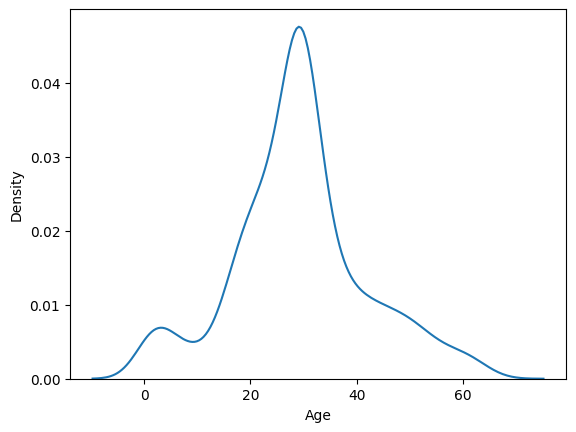

In [42]:
sns.kdeplot(data=train_x, x = 'Age')
# normal distribution tai Emperical rule kaje lagbe

<Axes: xlabel='Fare', ylabel='Density'>

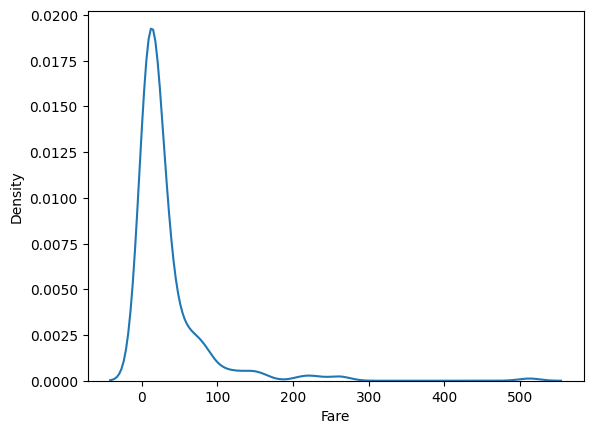

In [43]:
sns.kdeplot(data=train_x, x = 'Fare')
# plot kore dekhlam normal distribution nah eikhane IQR kaje lagbe

In [44]:
minimun_fare = min(0, minimun_fare)
maximum_fare = max(maximum_fare, 100)
train_x['Fare'] = train_x['Fare'].clip(minimun_fare, maximum_fare)
train_x

/tmp/ipykernel_4204/4064370004.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_x['Fare'] = train_x['Fare'].clip(minimun_fare, maximum_fare)


,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,age_outlires,fare_outlires
331,first,male,45.500000,0,0,28.5000,C124,S,1.231398e+00,-0.078628
733,second,male,23.000000,0,0,13.0000,Missing,S,-5.001304e-01,-0.376880
382,third,male,32.000000,0,0,7.9250,Missing,S,1.924808e-01,-0.474533
704,third,male,26.000000,1,0,7.8542,Missing,S,-2.692600e-01,-0.475896
813,third,female,6.000000,4,2,31.2750,Missing,S,-1.808396e+00,-0.025232
...,...,...,...,...,...,...,...,...,...,...
106,third,female,21.000000,0,0,7.6500,Missing,S,-6.540440e-01,-0.479825
270,first,male,29.498846,0,0,31.0000,Missing,S,2.734055e-16,-0.030523
860,third,male,41.000000,2,0,14.1083,Missing,S,8.850920e-01,-0.355554
435,first,female,14.000000,1,2,100.0000,B96 B98,S,-1.192742e+00,1.682019


In [45]:
dataa = pd.read_csv("/home/tanmoy/Desktop/Phitron/Machine Learning/Module6 - Outlires Ditection and Handling/Practice/marks_dataset.csv")
display(dataa.sample(5))

,student_name,maths_marks,science_marks,english_marks,social_studies_marks,language_marks
44,Reginald McCullough,13,88,17,6,59
81,Jeremy Metz,9,69,33,6,82
48,Mr. Neil Wunsch,78,83,91,77,34
13,Miss Madeline Parisian,30,86,92,89,70
60,Mr. Patrick Crona,65,34,47,83,31


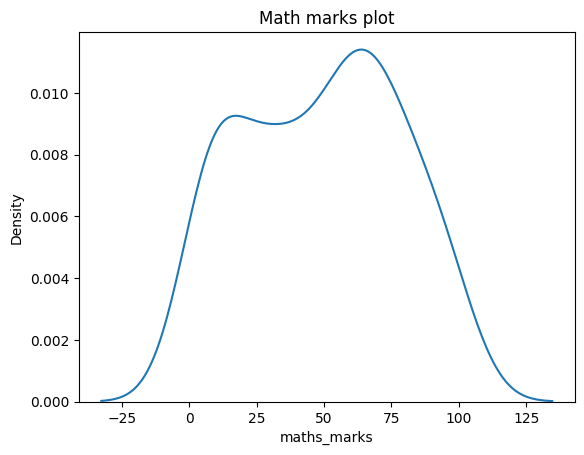

2

100

In [46]:
plt.title("Math marks plot")
sns.kdeplot(data=dataa, x = 'maths_marks')
plt.show()
display(min(dataa['maths_marks']))
display(max(dataa['maths_marks']))

In [47]:
mean_of_math_marks = dataa['maths_marks'].mean()
std_of_math_marks = dataa['maths_marks'].std()
dataa['z_score_math_marks'] = (dataa['maths_marks'] - mean_of_math_marks) / std_of_math_marks
display(dataa)

outlires_math_marks = abs(dataa['z_score_math_marks']) > 3
display(outlires_math_marks)

,student_name,maths_marks,science_marks,english_marks,social_studies_marks,language_marks,z_score_math_marks
0,Mr. Gregory Homenick,69,24,52,4,83,0.691380
1,Marlene Leffler IV,62,59,70,54,52,0.450001
2,Josephine Ebert,29,76,13,8,19,-0.687932
3,Dr. Irene Green,44,66,14,2,14,-0.170690
4,Jake Huel,49,23,63,86,68,0.001724
...,...,...,...,...,...,...,...
95,Renee Schinner,69,99,73,62,32,0.691380
96,Marguerite Ebert,32,62,82,99,42,-0.584484
97,Jorge Bednar,77,56,46,79,25,0.967243
98,Mrs. Roxanne Jacobi,54,66,70,49,20,0.174138


0     False
1     False
2     False
3     False
4     False
      ...  
95    False
96    False
97    False
98    False
99    False
Name: z_score_math_marks, Length: 100, dtype: bool

## Winsorization Technique 

In [56]:
x = 12
x = x / 100

min_val = dataa['maths_marks'].quantile(x)
max_val = dataa['maths_marks'].quantile(1 - x)

print(f"min value: {min_val} and maximun value: {max_val}")

min value: 9.879999999999999 and maximun value: 85.36000000000001


In [57]:
dataa['maths_marks'] = dataa['maths_marks'].clip(min_val, max_val)

In [58]:
dataa['maths_marks'].describe()

count    100.000000
mean      48.408800
std       26.731387
min        9.880000
25%       27.000000
50%       52.500000
75%       70.250000
max       85.360000
Name: maths_marks, dtype: float64